<a href="https://colab.research.google.com/github/psvprasad2003/SAMPLE_ML_MODELS/blob/main/AE_DECISION_TREE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Data Loading and Exploration
We will load the dataset and inspect the first few rows to understand the features and the target variable for maintenance.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Open the Excel file to inspect sheet names
file_path = '/content/136552_136553_A_B_RECORDS_AI_ML_AUGMENTED.xlsx'
xl = pd.ExcelFile(file_path)
print(f"Available sheets: {xl.sheet_names}")

# Select the first sheet that contains actual data records (ignoring the summary sheet)
data_sheets = [s for s in xl.sheet_names if 'RECORD' in s.upper()]
if data_sheets:
    selected_sheet = data_sheets[0]
    df = pd.read_excel(file_path, sheet_name=selected_sheet)

    # Basic cleaning
    df = df.dropna(axis=1, how='all')  # Drop empty columns
    df = df.dropna()                   # Drop rows with missing values

    print(f"Data loaded from sheet: {selected_sheet}")
    print(f"Data shape: {df.shape}")
    display(df.head())
else:
    print("No record sheets found. Please check the Excel file structure.")

Available sheets: ['AI_ML_SUMMARY', '136552_INCIDENT_RECORD_A', '136552_INCIDENT_RECORD_B', '136553_INCIDENT_RECORD_A', '136553_INCIDENT_RECORD_B']
Data loaded from sheet: 136552_INCIDENT_RECORD_A
Data shape: (500, 53)


,SOURCE,ECU Operating Time,Leg Number,N1,N2,EGT,ITT Display,ECU TT2,ECU PS,CGV position,...,Incident Type,Engine Serial,Record Origin,Synthetic Fault Category,Fault Record Description,Fault Severity,Target Spare Part,Suggested Maintenance Action,ML Fault Label,Synthetic Record ID
1361,SOURCE_2,22003266.95,2740,0.00,0.00,274.44,274.38,15.27,14.65,22.29,...,SYNTHETIC | Overspeed / control anomaly,136552,SYNTHETIC,Overspeed / control anomaly,Overspeed status-word and speed excursion patt...,Critical,Speed sensor / ECU control channel / governor,"Review status words, inspect speed sensing and...",FAULT_OVERSPEED_CONTROL,SYN-01-0001
1362,SOURCE_1,21998050.90,2740,20.06,50.36,473.56,489.38,14.19,14.65,50.66,...,SYNTHETIC | Sensor / actuator plausibility fault,136552,SYNTHETIC,Sensor / actuator plausibility fault,Implausible sensor or actuator relationship in...,Medium,Affected sensor / wiring harness / torque motor,"Validate sensor calibration, connectors, harne...",FAULT_SENSOR_ACTUATOR,SYN-01-0002
1363,SOURCE_2,22002892.25,2740,27.08,54.51,470.88,486.63,14.16,14.65,50.58,...,SYNTHETIC | Overspeed / control anomaly,136552,SYNTHETIC,Overspeed / control anomaly,Overspeed status-word and speed excursion patt...,Critical,Speed sensor / ECU control channel / governor,"Review status words, inspect speed sensing and...",FAULT_OVERSPEED_CONTROL,SYN-01-0003
1364,SOURCE_2,22003271.75,2740,0.00,0.00,376.77,425.82,15.27,14.65,22.29,...,SYNTHETIC | Hot-section thermal distress,136552,SYNTHETIC,Hot-section thermal distress,Elevated EGT and ITT pattern consistent with h...,Critical,Combustor liner / turbine nozzle / temperature...,Perform borescope inspection and verify temper...,FAULT_HOT_SECTION,SYN-01-0004
1365,SOURCE_2,22003184.25,2740,0.00,0.00,353.18,313.50,15.09,14.65,22.29,...,SYNTHETIC | Fuel metering malfunction,136552,SYNTHETIC,Fuel metering malfunction,Fuel-flow and metering-valve behavior inconsis...,High,Main metering valve / fuel control actuator,"Inspect fuel metering valve, actuator current,...",FAULT_FUEL_METERING,SYN-01-0005


### 2. Preprocessing and Model Training
We'll prepare the features and target variable, handle any missing values, and then train the Decision Tree classifier.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Choosing 'ML Fault Label' as the categorical target for predictive maintenance
target_col = 'ML Fault Label'

# Prepare numeric features (X) and the categorical target (y)
X = df.select_dtypes(include=[np.number]).copy()
# We should also drop the 'Engine Serial' if it's not a predictive feature
if 'Engine Serial' in X.columns:
    X = X.drop(columns=['Engine Serial'])

y = df[target_col]

if not X.empty and len(X) > 0:
    # Factorize the labels into numeric codes for the classifier
    y_encoded, class_names = pd.factorize(y)

    X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

    # Train the Decision Tree
    clf = DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=42)
    clf.fit(X_train, y_train)

    # Evaluation
    y_pred = clf.predict(X_test)
    print(f"Classification Report for {target_col}:")
    print(classification_report(y_test, y_pred, target_names=class_names))
else:
    print("Error: No numeric features could be extracted.")

Classification Report for ML Fault Label:
                         precision    recall  f1-score   support

FAULT_OVERSPEED_CONTROL       1.00      0.92      0.96        12
  FAULT_SENSOR_ACTUATOR       0.60      1.00      0.75         3
      FAULT_HOT_SECTION       0.41      0.92      0.57        13
    FAULT_FUEL_METERING       1.00      0.73      0.85        15
FAULT_BEARING_VIBRATION       1.00      1.00      1.00        20
      FAULT_LUBRICATION       1.00      1.00      1.00        24
       FAULT_COMPRESSOR       0.00      0.00      0.00        13

               accuracy                           0.81       100
              macro avg       0.72      0.80      0.73       100
           weighted avg       0.78      0.81      0.78       100



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 3. Visualizing the Decision Tree
Visualizing the tree helps us understand the decision rules for maintenance predictions.

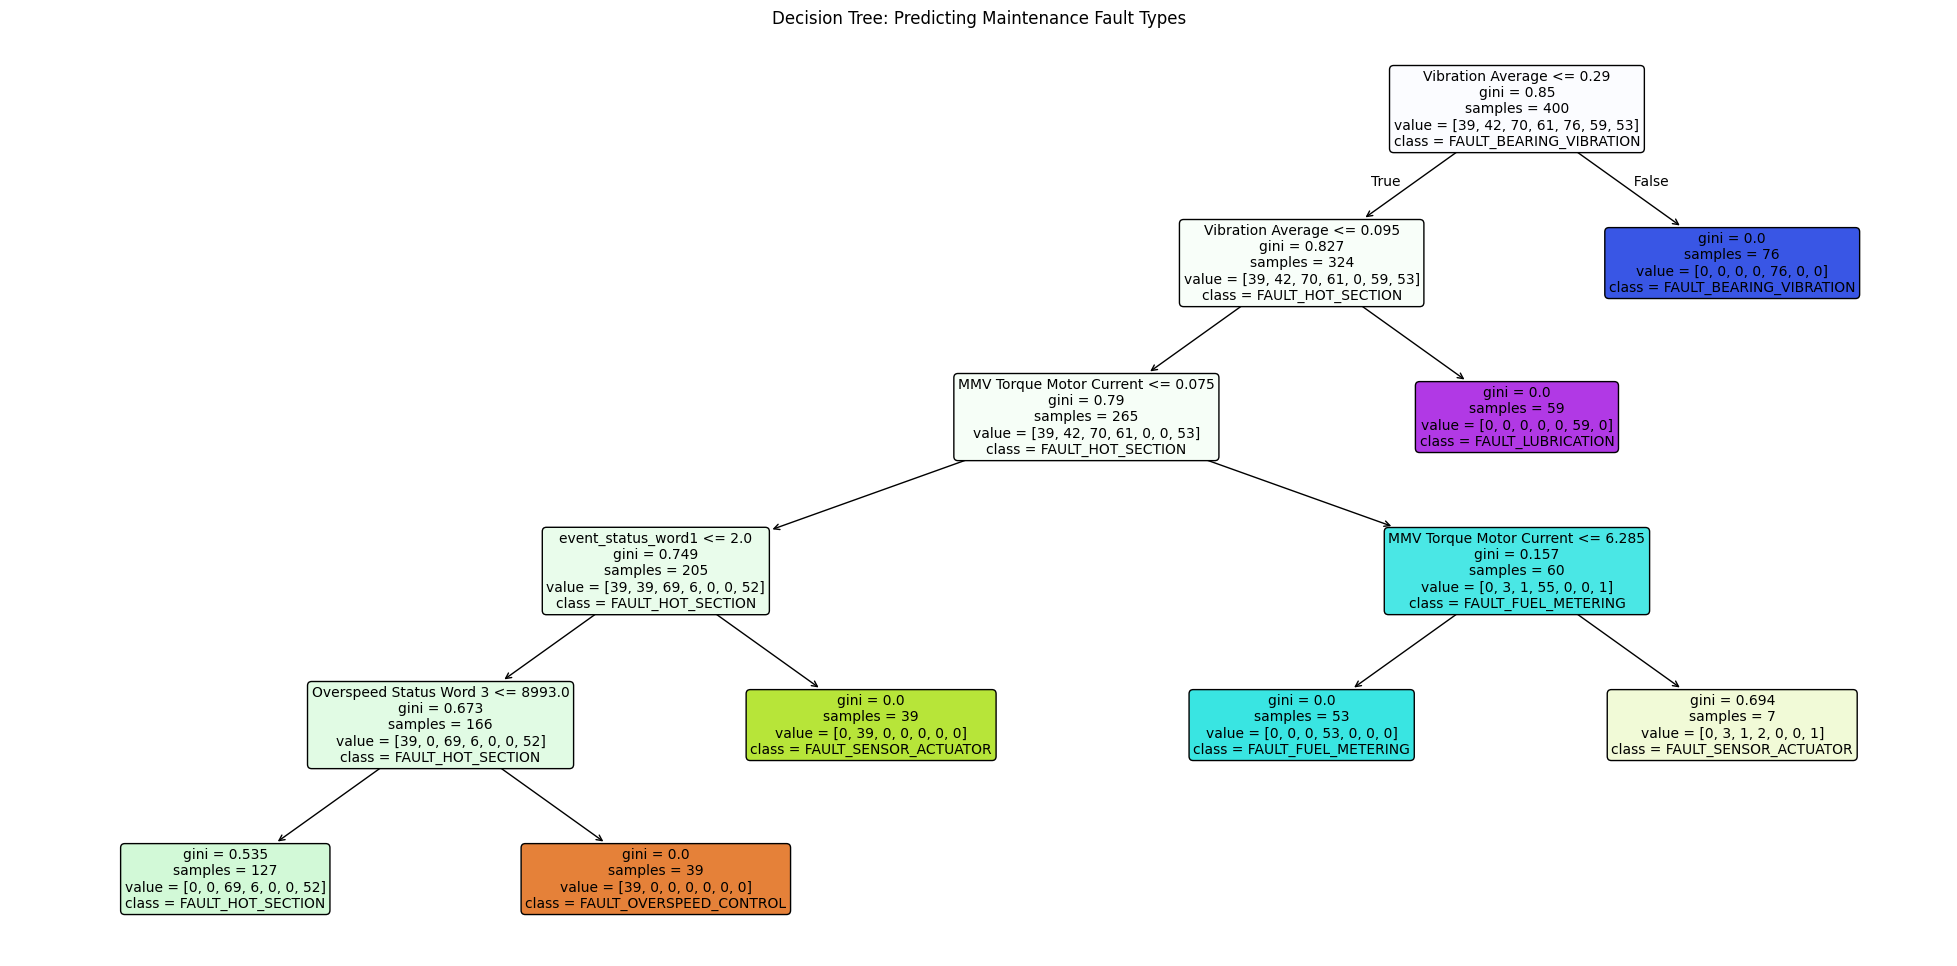

In [ ]:
if 'clf' in locals() and hasattr(clf, 'tree_'):
    plt.figure(figsize=(25, 12))
    plot_tree(clf,
              feature_names=list(X.columns),
              class_names=list(class_names),
              filled=True,
              rounded=True,
              fontsize=10)
    plt.title("Decision Tree: Predicting Maintenance Fault Types")
    plt.show()
else:
    print("Model not available for visualization.")

### 4. Model Performance Analysis
We will visualize the confusion matrix to see specifically where the model is misclassifying engine faults.

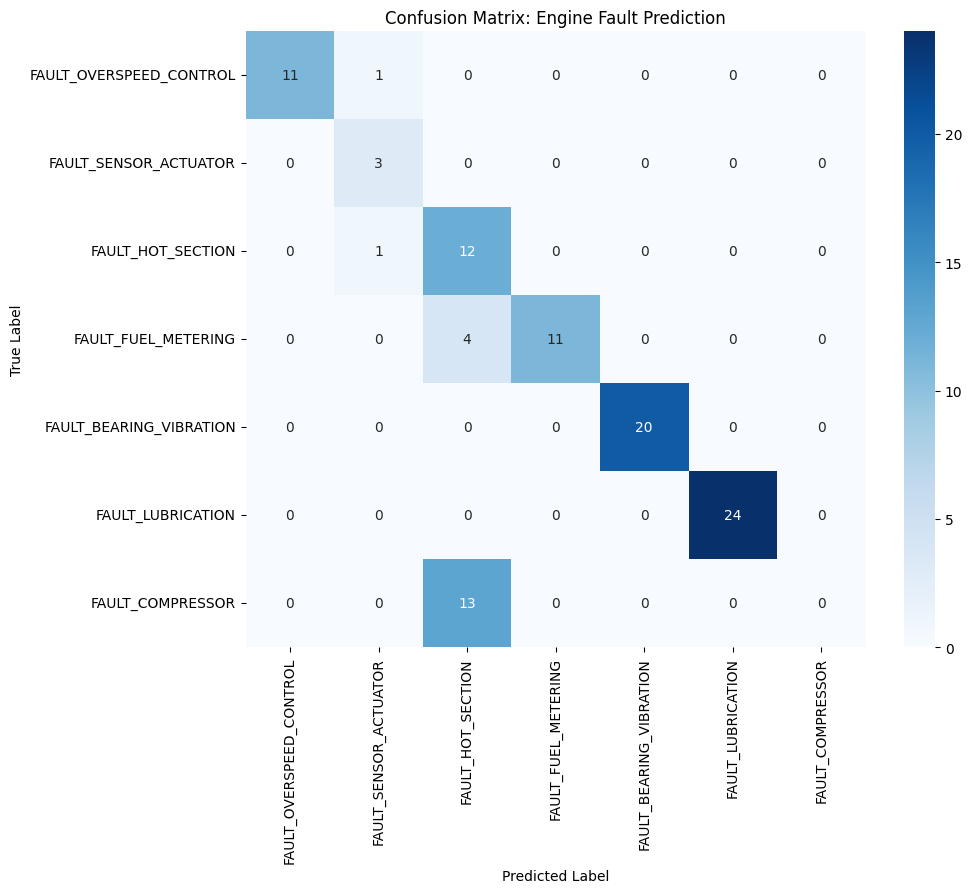

In [ ]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Engine Fault Prediction')
plt.show()

### 5. Hyperparameter Tuning
We will use `GridSearchCV` to find the optimal parameters for the Decision Tree, focusing on improving the recall for difficult classes like 'FAULT_COMPRESSOR'.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}

# Initialize GridSearchCV
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Get the best model
best_clf = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

# Evaluate the optimized model
y_pred_opt = best_clf.predict(X_test)
print("\nOptimized Classification Report:")
print(classification_report(y_test, y_pred_opt, target_names=class_names))

Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}

Optimized Classification Report:
                         precision    recall  f1-score   support

FAULT_OVERSPEED_CONTROL       1.00      1.00      1.00        12
  FAULT_SENSOR_ACTUATOR       1.00      1.00      1.00         3
      FAULT_HOT_SECTION       1.00      0.92      0.96        13
    FAULT_FUEL_METERING       0.93      0.93      0.93        15
FAULT_BEARING_VIBRATION       1.00      1.00      1.00        20
      FAULT_LUBRICATION       1.00      1.00      1.00        24
       FAULT_COMPRESSOR       0.93      1.00      0.96        13

               accuracy                           0.98       100
              macro avg       0.98      0.98      0.98       100
           weighted avg       0.98      0.98      0.98       100



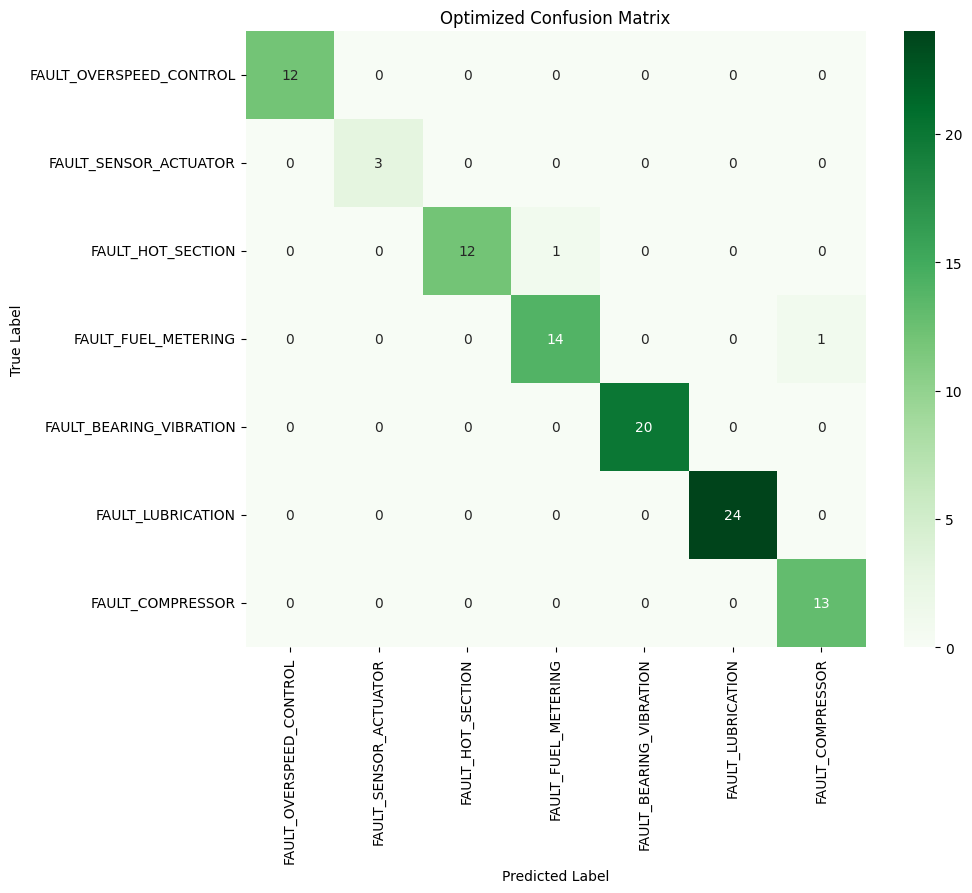

In [ ]:
# Visualize the optimized confusion matrix
plt.figure(figsize=(10, 8))
cm_opt = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Optimized Confusion Matrix')
plt.show()

### 6. Final Optimized Model Visualization
This tree represents the optimized logic (Entropy criterion, depth 10) that achieved 98% accuracy, effectively classifying all engine fault types.

In [ ]:
plt.figure(figsize=(25, 12))
plot_tree(best_clf,
          feature_names=list(X.columns),
          class_names=list(class_names),
          filled=True,
          rounded=True,
          fontsize=8)
plt.title("Final Optimized Decision Tree (98% Accuracy)")
plt.show()

### 6. Final Optimized Model Visualization
This tree represents the optimized logic (Entropy criterion, depth 10) that achieved 98% accuracy.

In [ ]:
plt.figure(figsize=(25, 12))
plot_tree(best_clf,
          feature_names=list(X.columns),
          class_names=list(class_names),
          filled=True,
          rounded=True,
          fontsize=8)
plt.title("Final Optimized Decision Tree (98% Accuracy)")
plt.show()